# Residual Stream Lab on Qwen3-4B

Goal: one notebook you could show someone, with a plot, where you have **read** the prompts and outputs — not just a number.

Sequence (Neel, time-constrained):
1. Load, tokenize, next-token logits / top-5. Check against a chat UI.
2. Cache residual-stream activations. Plot **logit lens**: at which layer is the answer linearly readable?
3. Mean-difference **steering vector** (happy vs sad) + **same-norm random** baseline.
4. If time: one **activation patch** on a clean/corrupt pair.
5. Sweep that patch over **every (layer, position)** — one cell of a grid is not a result.
6. **Direct logit attribution** per head and per MLP: which components write the answer?

Not today: SAEs, fine-tuning, ARENA 1.1. Sections 5–6 are the first two steps toward circuit-finding, but stop short of it: they find sufficiency and last-hop writes, never composition between heads.

Use this repo’s model: `Qwen/Qwen3-4B-Instruct-2507` (plain dense GQA, not Qwen 3.5 hybrid/VL). GPT-2 is fine as an ARENA tutorial later; it is not the subject of this notebook.

Kernel: this repo’s `.venv` (`uv run jupyter notebook` or `uv run jupyter lab` from the **repo root**).

**Visualizations** (cells marked *viz*, after each step): `src/viz.py` plus
[lovely-tensors](https://github.com/xl0/lovely-tensors) (what tensor is this),
[circuitsvis](https://github.com/TransformerLensOrg/CircuitsVis) (Neel/ARENA: attention + colored tokens),
plotly (hoverable charts), seaborn/matplotlib (residual-stack cartoon, PCA),
torchinfo (module tree, no extra forward), pandas (token table).
Not installed: TransformerLens (ARENA later). Bertviz is skipped — same job as circuitsvis, and it wants eager attention globally.

In [16]:
print("hello")

hello


## Residual-stream picture (what stays the same for interp)

In [17]:
# x₀ = embed(tokens)          # GPT-2 also + pos; Qwen3 pos is inside attention (RoPE)
# for each block:
#     x += Attn(Norm(x))      # GQA + RoPE + QK-norm vs MHA + absolute pos
#     x += MLP(Norm(x))       # SwiGLU vs GELU
# x = Norm(x)                 # RMSNorm vs LayerNorm
# logits = lm_head(x)
# comment

## 0. Load once

Env vars and the MPS transfer workaround live in `src.model_utils` — import that **before** thinking about `torch` yourself. In torch 2.13 on MPS, `tensor.to("cpu", torch.float32)` silently misreads sliced bf16 tensors (`logits[0, -1]`, `h[:, -1]`). Always use `to_cpu_f32`.

In [18]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "src" / "model_utils.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.model_utils import (
    DEFAULT_REPO_ID,
    build_prompt,
    cache_residual,
    generate,
    get_blocks,
    get_ln_f,
    load_model,
    tokenize,
    to_cpu_f32,
    _block_output,
)
from src.viz import (
    attention_patterns_at_layer,
    cache_residual_seq,
    colored_token_norms,
    draw_residual_stack,
    model_card,
    pca_two_clouds,
    plot_head_attribution,
    plot_layer_attribution,
    plot_logit_lens,
    plot_patch_heatmap,
    plot_patch_logits,
    plot_top5,
    print_architecture,
    show_tensor,
    show_token_stream,
    token_table,
)

import torch
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

print("repo", DEFAULT_REPO_ID)
print("torch", torch.__version__, "mps", torch.backends.mps.is_available())

model, tok = load_model(DEFAULT_REPO_ID, dtype=torch.bfloat16, device="mps")
device = next(model.parameters()).device
blocks = get_blocks(model)
ln_f = get_ln_f(model)
unembed = model.lm_head
n_layers = len(blocks)
print(f"layers={n_layers}  hidden={model.config.hidden_size}  device={device}")

repo Qwen/Qwen3-4B-Instruct-2507
torch 2.13.0 mps True


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

layers=36  hidden=2560  device=mps:0


,class,layers,hidden,heads,kv_heads,head_dim,vocab,attn,params_B,device,dtype
0,Qwen3ForCausalLM,36,2560,32,8,128,151936,sdpa,4.022,mps:0,bfloat16


Layer (type:depth-idx)                             Param #
Qwen3ForCausalLM                                   --
├─Qwen3Model: 1-1                                  4,022,468,096
├─Linear: 1-2                                      388,956,160
Total params: 4,411,424,256
Trainable params: 4,411,424,256
Non-trainable params: 0
embed_tokens [vocab, hidden]: tensor[151936, 2560] n=388956160 (1.45 GiB) x∈[-0.221 |  ▁▁█▄▁▁  | 0.246] μ=-2.643e-05 σ=0.022
lm_head / unembed [vocab, hidden]: tensor[151936, 2560] n=388956160 (1.45 GiB) x∈[-0.221 |  ▁▁█▄▁▁  | 0.246] μ=-2.643e-05 σ=0.022


/Users/mbp_qasim/repos/mech_interp/src/viz.py:189: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


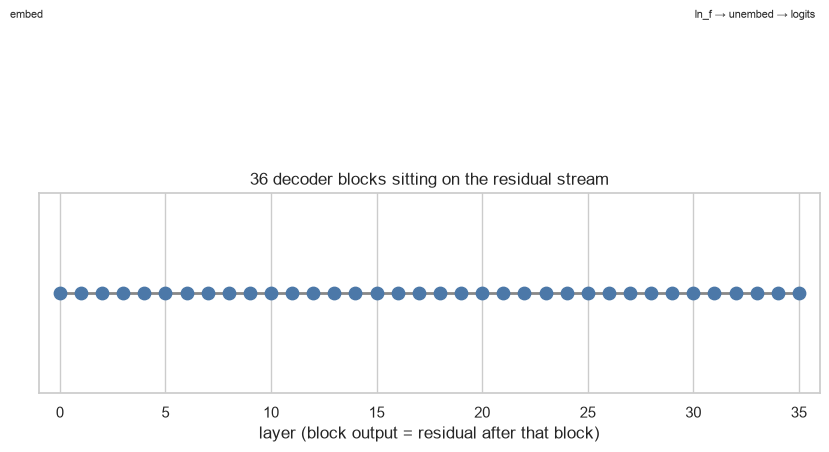

In [3]:
# viz — what model is this? Safe to run on a kernel that already has `model` loaded
# (imports only — does not call load_model). torchinfo does *not* run a forward.
from IPython.display import display
from src.viz import (
    attention_patterns_at_layer,
    cache_residual_seq,
    colored_token_norms,
    draw_residual_stack,
    model_card,
    pca_two_clouds,
    plot_head_attribution,
    plot_layer_attribution,
    plot_logit_lens,
    plot_patch_heatmap,
    plot_patch_logits,
    plot_top5,
    print_architecture,
    show_tensor,
    show_token_stream,
    token_table,
)

display(model_card(model))
print_architecture(model, depth=1)
show_tensor(model.model.embed_tokens.weight, "embed_tokens [vocab, hidden]")
show_tensor(unembed.weight, "lm_head / unembed [vocab, hidden]")
draw_residual_stack(n_layers, title="36 decoder blocks sitting on the residual stream")
plt.show()

## 1. One prompt, next-token logits, top-5

The #1 silent failure is the **chat template**. Instruct models wrap your string in user/assistant markers; the last token is the assistant-turn prefix, not the last user character. If this decoded prompt does not match what a chat UI would send, every later experiment is about a different input.

**You do this by eye:** paste the same user text into a Qwen3-4B-Instruct chat (or the Hub inference widget) and check that the first generated tokens agree with `top-5` / greedy decode below.

In [ ]:
USER = "What is the capital of France? Answer with one word."

# Always print the *templated* string. If you don't see <|im_start|>assistant at the end,
# you are not talking to the instruct model the way it was trained.
text = build_prompt(tok, USER)
print("TEMPLATED PROMPT:")
print(repr(text))

enc = tokenize(tok, [USER], max_length=128, device=str(device))
print("n_tokens", enc["input_ids"].shape[1], "last token", tok.decode(enc["input_ids"][0, -1:]))

print(enc)
print(enc["input_ids"][0][-1])
print(repr(tok.decode(enc["input_ids"][0][-1])))


with torch.inference_mode():
    logits = model(**enc).logits[0, -1]  # [vocab] at the last prompt token

probs = to_cpu_f32(logits).softmax(dim=-1)
top = torch.topk(probs, 5)
print("\nTOP-5 NEXT TOKENS")
for p, idx in zip(top.values.tolist(), top.indices.tolist()):
    print(f"  {p:6.3f}  {idx:6d}  {tok.decode([idx])!r}")

print("\nGREEDY CONTINUATION")
print(generate(model, tok, [USER], max_new_tokens=16)[0])

# TODO: change USER and re-run. Then check a chat UI. If they disagree, stop —
# it is almost always the template, padding_side, or a different checkpoint.

TEMPLATED PROMPT:
'<|im_start|>user\nWhat is the capital of France? Answer with one word.<|im_end|>\n<|im_start|>assistant\n'
n_tokens 20 last token 

{'input_ids': tensor([[151644,    872,    198,   3838,    374,    279,   6722,    315,   9625,
             30,  21806,    448,    825,   3409,     13, 151645,    198, 151644,
          77091,    198]], device='mps:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]],
       device='mps:0')}
tensor(198, device='mps:0')
'\n'

TOP-5 NEXT TOKENS
   1.000   59604  'Paris'
   0.000  106004  '巴黎'
   0.000   12095  ' Paris'
   0.000    4272  'Par'
   0.000   16567  'PAR'

GREEDY CONTINUATION
['Paris']


,pos,id,piece,text,pad,special,readout,role
0,0,151644,<|im_start|>,<|im_start|>,False,True,False,special
1,1,872,user,user,False,False,False,content
2,2,198,Ċ,\n,False,False,False,content
3,3,3838,What,What,False,False,False,content
4,4,374,Ġis,is,False,False,False,content
5,5,279,Ġthe,the,False,False,False,content
6,6,6722,Ġcapital,capital,False,False,False,content
7,7,315,Ġof,of,False,False,False,content
8,8,9625,ĠFrance,France,False,False,False,content
9,9,30,?,?,False,False,False,content


logits at last prompt token [vocab]: tensor[151936] 594 KiB x∈[-28.250 |▁▁▁▁██▁▁  | 34.000] μ=2.677 σ=3.267


attention layer 0: tensor[32, 20, 20] n=12800 (50 KiB) x∈[0. |█▁▁▁▁▁▁▁▁▁| 1.000] μ=0.050 σ=0.149


attention layer 35: tensor[32, 20, 20] n=12800 (50 KiB) x∈[0. |█▁▁▁▁▁▁▁▁▁| 1.000] μ=0.050 σ=0.179


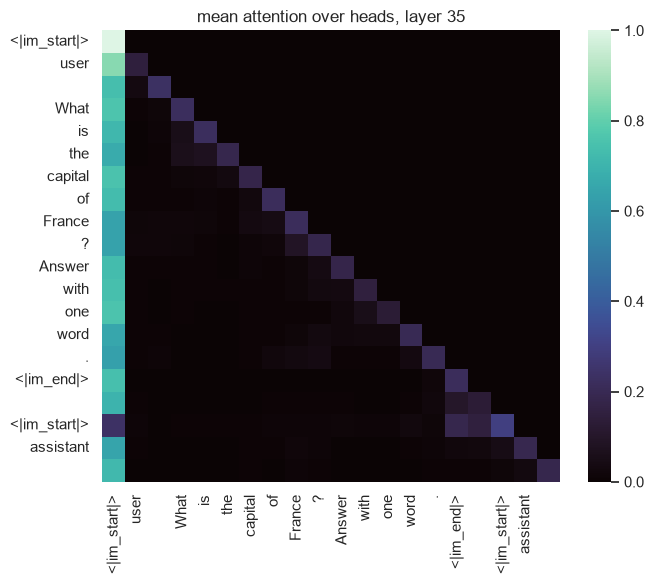

In [26]:
# viz — token stream + next-token distribution. Orange chip = readout position (not the last user character).
from IPython.display import display
import circuitsvis as cv

df_tok = show_token_stream(tok, enc, title="templated prompt")
display(df_tok)  # pos / id / piece / pad / readout
show_tensor(logits, "logits at last prompt token [vocab]")
plot_top5(tok, probs, k=5).show()

# Attention at one layer. Temporarily uses eager attn (SDPA has no weights), then SDPA is restored.
ATTN_LAYER = 0  # early layer: often positional / previous-token heads
attn = attention_patterns_at_layer(model, enc, ATTN_LAYER)  # [heads, q, k]
show_tensor(attn, f"attention layer {ATTN_LAYER}")
pieces = [tok.decode([i]) or tok.convert_ids_to_tokens(i) for i in enc["input_ids"][0].tolist()]
display(cv.attention.attention_patterns(tokens=pieces, attention=attn))


# Attention at LAST layer. Temporarily uses eager attn (SDPA has no weights), then SDPA is restored.
ATTN_LAYER = n_layers - 1  # 35, last block
attn = attention_patterns_at_layer(model, enc, ATTN_LAYER)  # [heads, q, k]
show_tensor(attn, f"attention layer {ATTN_LAYER}")
pieces = [tok.decode([i]) or tok.convert_ids_to_tokens(i) for i in enc["input_ids"][0].tolist()]
display(cv.attention.attention_patterns(tokens=pieces, attention=attn))

# Fallback if circuitsvis is blank in Cursor: mean attention over heads.
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(attn.mean(0).numpy(), xticklabels=pieces, yticklabels=pieces, ax=ax, cmap="mako")
ax.set_title(f"mean attention over heads, layer {ATTN_LAYER}")
plt.xticks(rotation=90)
fig.tight_layout()
fig.savefig(FIGURES / "attention_layer0_mean.png", dpi=140)
plt.show()

## 2. Residual stream + logit lens

The residual stream is the running hidden state after each decoder block (`blocks[i]` output). **Logit lens:** apply the *final* layer-norm and unembed at every layer, and ask when the target token’s logit / rank takes off. That is a readout, not a causal claim (later layers can still overwrite it).

Use the same `ln_f` (`model.model.norm`) at every layer — not “unembed raw residual” (that fails the smoke test) and not a per-layer trained lens.

Pick a target whose **first token** is what you care about (`Paris` is one token here; check with `tok.encode`).

target Paris id 59604 decoded Paris


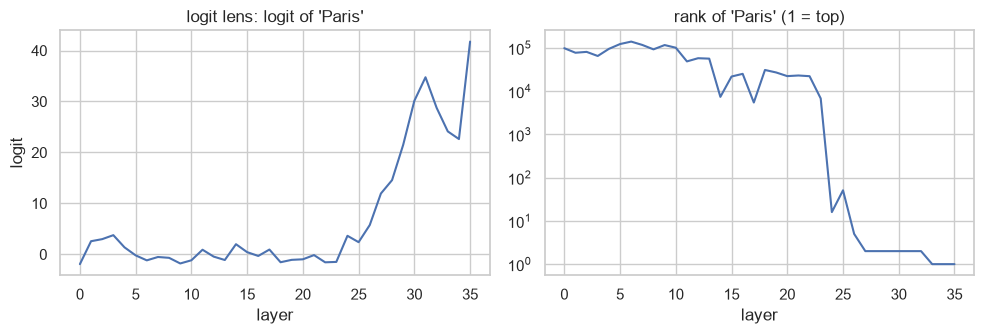

saved /Users/mbp_qasim/repos/mech_interp/figures/logit_lens.png
rank at last layer 1 logit 41.75


In [6]:
TARGET = "Paris"  # must match the answer you expect for USER
target_id = tok.encode(TARGET, add_special_tokens=False)[0]
print("target", TARGET, "id", target_id, "decoded", tok.decode([target_id]))

# One forward, hooks on every block, last non-pad position only → {layer: [1, hidden]} on CPU.
cache = cache_residual(model, tok, [USER], layers=list(range(n_layers)), max_length=128)

ranks, target_logits = [], []
with torch.inference_mode():
    for i in range(n_layers):
        h = cache[i].to(device=device, dtype=torch.bfloat16)  # [1, d]
        layer_logits = unembed(ln_f(h))[0]  # [vocab]
        layer_logits = to_cpu_f32(layer_logits)
        target_logits.append(layer_logits[target_id].item())
        ranks.append(int((layer_logits > layer_logits[target_id]).sum().item()) + 1)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(target_logits)
ax[0].set_title(f"logit lens: logit of {TARGET!r}")
ax[0].set_xlabel("layer")
ax[0].set_ylabel("logit")
ax[1].plot(ranks)
ax[1].set_yscale("log")
ax[1].set_title(f"rank of {TARGET!r} (1 = top)")
ax[1].set_xlabel("layer")
fig.tight_layout()
fig.savefig(FIGURES / "logit_lens.png", dpi=140)
plt.show()
print("saved", FIGURES / "logit_lens.png")
print("rank at last layer", ranks[-1], "logit", f"{target_logits[-1]:.2f}")

# Write one sentence: at which layer does rank collapse? Is that “the model knows”
# or just “the unembed can read it”? Logit lens cannot tell those apart.

/Users/mbp_qasim/repos/mech_interp/src/viz.py:189: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


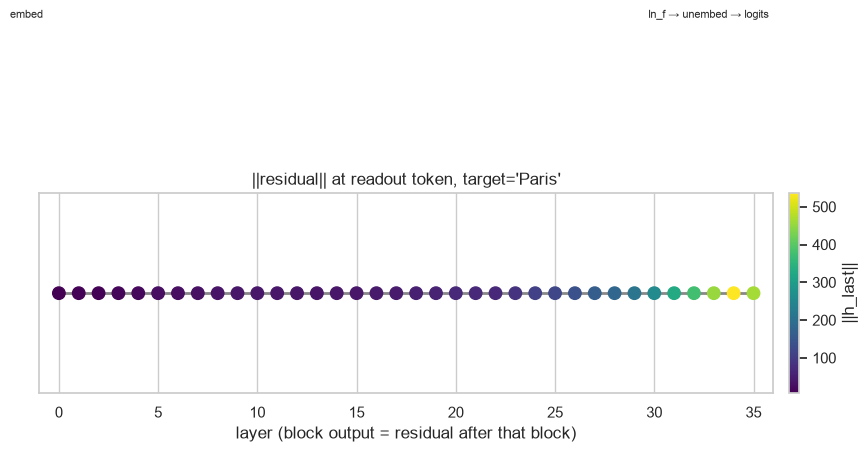

full residual at layer 18
h[seq, hidden] layer 18: tensor[20, 2560] n=51200 (200 KiB) x∈[-1.992e+03 |  █       | 7.456e+03] μ=0.113 σ=34.193
||h_t|| by token at layer 18 (circuitsvis)


In [7]:
# viz — logit lens: hover a layer; residual-stack color = ||h|| at the readout token.
plot_logit_lens(TARGET, target_logits, ranks).show()
norms = [float(cache[i][0].norm()) for i in range(n_layers)]
draw_residual_stack(n_layers, norms=norms, title=f"||residual|| at readout token, target={TARGET!r}")
plt.savefig(FIGURES / "residual_stack_norms.png", dpi=140)
plt.show()

# One extra forward: residual at *every* position, mid layer, colored onto tokens.
MID = n_layers // 2
h_seq = cache_residual_seq(model, enc, MID)  # [seq, hidden]
print(f"full residual at layer {MID}")
show_tensor(h_seq, f"h[seq, hidden] layer {MID}")
colored_token_norms(tok, enc, h_seq.norm(dim=-1), title=f"||h_t|| by token at layer {MID} (circuitsvis)")

## 3. Steering vector + random baseline

Neel’s cheap exercise: mean residual(happy) − mean residual(sad) at a mid layer. Add `coeff * v` to the residual stream **during generation**. 

**Baseline that makes this a real experiment:** a random vector with the **same norm**. If random matches your steer, you have not shown a sentiment direction — you have shown that shoving the residual around changes the text.

Design choices (not optional to notice):
- layer: mid (`n_layers // 2`) is a starting point, not a theorem
- where: we add to the **block output**, every token, every decode step
- coeff: start around 1–2; too large → garbage

Bump the lists toward 32/32 if this looks like a real effect. **Read every completion.** A score you did not read is not a result.

In [27]:
HAPPY = [
    "Write a sentence about a wonderful day.",
    "Describe a joyful reunion in one sentence.",
    "Say something cheerful about the morning.",
    "Write one happy sentence about a birthday.",
    "Describe a delightful surprise in one sentence.",
    "Say something upbeat about the weekend.",
    "Write a cheerful sentence about sunshine.",
    "Describe a moment of laughter in one sentence.",
]
SAD = [
    "Write a sentence about a miserable day.",
    "Describe a painful goodbye in one sentence.",
    "Say something gloomy about the morning.",
    "Write one sad sentence about a funeral.",
    "Describe a disappointing surprise in one sentence.",
    "Say something downbeat about the weekend.",
    "Write a bleak sentence about rain.",
    "Describe a moment of grief in one sentence.",
]
# TODO: add more until you have ~32 each if you want a less noisy vector.

STEER_LAYER = n_layers // 2
print("steering at layer", STEER_LAYER)

happy_h = cache_residual(model, tok, HAPPY, layers=STEER_LAYER, max_length=128)[STEER_LAYER]
sad_h = cache_residual(model, tok, SAD, layers=STEER_LAYER, max_length=128)[STEER_LAYER]
# [n, d] float32 CPU, last prompt token
steer = happy_h.mean(0) - sad_h.mean(0)
rng = torch.Generator().manual_seed(0)
rand = torch.randn(steer.shape, generator=rng)
rand = rand * (steer.norm() / rand.norm().clamp_min(1e-8))
print("steer norm", float(steer.norm()), "rand norm", float(rand.norm()))

steering at layer 18
steer norm 9.44456672668457 rand norm 9.444565773010254


steer = mean(happy) − mean(sad): tensor[2560] 10 KiB x∈[-0.932 |▁▁▂██▂▁▁▁▁| 1.419] μ=0.001 σ=0.187
random, same L2 norm: tensor[2560] 10 KiB x∈[-0.584 |▁▁▄▇█▆▃▁▁▁| 0.760] μ=0.002 σ=0.187


/Users/mbp_qasim/repos/mech_interp/src/viz.py:189: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


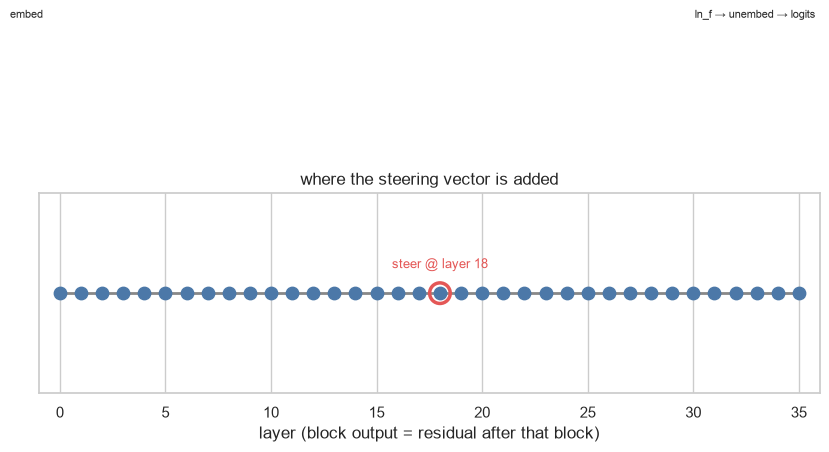

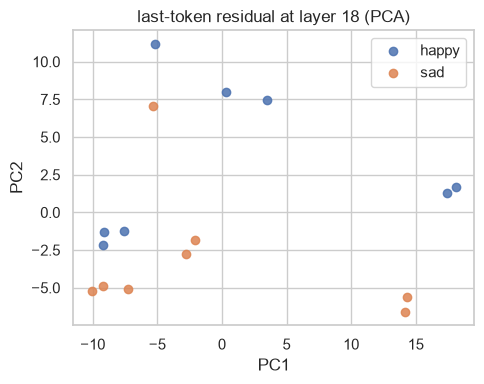

In [28]:
# viz — steering vector: same-norm random should *not* look like happy−sad in PCA.
# Orange ring = the layer we will add the vector to (every token, every decode step).
show_tensor(steer, "steer = mean(happy) − mean(sad)")
show_tensor(rand, "random, same L2 norm")
draw_residual_stack(
    n_layers,
    highlight=STEER_LAYER,
    highlight_label=f"steer @ layer {STEER_LAYER}",
    title="where the steering vector is added",
)
plt.show()
fig, ax = pca_two_clouds(
    happy_h, sad_h, "happy", "sad",
    f"last-token residual at layer {STEER_LAYER} (PCA)",
)
fig.savefig(FIGURES / "steer_pca.png", dpi=140)
plt.show()

In [29]:
def generate_with_add(prompts, vec, coeff, max_new_tokens=40):
    """Add coeff * vec to decoder-block output at STEER_LAYER, all positions, all decode steps."""
    add = vec.to(device=device, dtype=torch.bfloat16)

    def hook(_mod, _inp, out):
        h = _block_output(out)
        h = h + coeff * add  # broadcasts over [batch, seq, d]
        return (h, *out[1:]) if isinstance(out, tuple) else h

    handle = blocks[STEER_LAYER].register_forward_hook(hook)
    try:
        return generate(model, tok, prompts, max_new_tokens=max_new_tokens)
    finally:
        handle.remove()  # leaked hooks are how results change between cells


TEST = [
    "Write one sentence about the weather.",
    "Describe a walk through the city in one sentence.",
    "Say something about tomorrow.",
]
COEFF = 1.5  # try 0.5, 1.5, 3.0; too big → nonsense

conditions = {
    "none": lambda p: generate(model, tok, p, max_new_tokens=40),
    "happy_steer": lambda p: generate_with_add(p, steer, COEFF),
    "sad_steer": lambda p: generate_with_add(p, steer, -COEFF),
    "random": lambda p: generate_with_add(p, rand, COEFF),
}

for name, fn in conditions.items():
    print("\n========", name, "========")
    for prompt, out in zip(TEST, fn(TEST)):
        print(f"Q: {prompt}")
        print(f"A: {out}\n")

# Checkpoint: did happy_steer actually sound happier than none? Did random do the same
# thing? If random ≈ steer, the vector is not doing what you think.


======== none ========
Q: Write one sentence about the weather.
A: The sky is clear and bright, with a gentle breeze making the day feel perfect.

Q: Describe a walk through the city in one sentence.
A: The city pulses with life—streetlights flicker in rhythm with the hum of traffic, the scent of coffee and exhaust mixes in the air, and laughter spills from open doors as pedestrians weave through bustling

Q: Say something about tomorrow.
A: Tomorrow is a new beginning, full of possibilities and quiet potential. It’s the day when dreams might take shape, when small choices can lead to big changes, and when even the simplest moments—like


======== happy_steer ========
Q: Write one sentence about the weather.
A: The weather is sunny and warm today, perfect for a picnic! 🌞😊

Q: Describe a walk through the city in one sentence.
A: Sunlight dapples through the trees as you stroll down the city’s vibrant streets, where laughter echoes from a bustling market, street performers dazzle with m

### Extra steering checks

Same setup, four cheap tests. Read the text; no scores.

1. **Matched pairs** — same sentence skeleton, one-word flip, then the original TEST prompts.
2. **Layer** — rebuild happy−sad at layers 0 / mid / last; one weather sentence each.
3. **Coeff** — volume knob on the existing mid-layer vector.
4. **Steer vs prompt** — ask for gloom, add `+happy`. Does the vector override the instruction?

In [30]:
N_NEW = 24  # short completions
WEATHER = ["Write one sentence about the weather."]

def add_at(prompts, vec, coeff, layer, max_new_tokens=N_NEW):
    """Like generate_with_add, but the layer is an argument."""
    add = vec.to(device=device, dtype=torch.bfloat16)

    def hook(_mod, _inp, out):
        h = _block_output(out)
        h = h + coeff * add
        return (h, *out[1:]) if isinstance(out, tuple) else h

    handle = blocks[layer].register_forward_hook(hook)
    try:
        return generate(model, tok, prompts, max_new_tokens=max_new_tokens)
    finally:
        handle.remove()


print("======== 1. MATCHED-PAIR VECTOR ========")
# Same frames as HAPPY/SAD, but the only intended change is the mood word.
HAPPY_M = [
    "Write a sentence about a wonderful day.",
    "Describe a joyful reunion in one sentence.",
    "Say something cheerful about the morning.",
    "Write one happy sentence about a birthday.",
    "Describe a delightful surprise in one sentence.",
    "Say something upbeat about the weekend.",
    "Write a cheerful sentence about the weather.",
    "Describe a moment of laughter in one sentence.",
]
SAD_M = [
    "Write a sentence about a miserable day.",
    "Describe a painful reunion in one sentence.",
    "Say something gloomy about the morning.",
    "Write one sad sentence about a birthday.",
    "Describe a disappointing surprise in one sentence.",
    "Say something downbeat about the weekend.",
    "Write a bleak sentence about the weather.",
    "Describe a moment of tears in one sentence.",
]
h_m = cache_residual(model, tok, HAPPY_M, layers=STEER_LAYER, max_length=128)[STEER_LAYER]
s_m = cache_residual(model, tok, SAD_M, layers=STEER_LAYER, max_length=128)[STEER_LAYER]
steer_m = h_m.mean(0) - s_m.mean(0)
for name, c in [("matched +happy", COEFF), ("matched −happy", -COEFF)]:
    print("\n-----", name, "-----")
    for q, a in zip(TEST, add_at(TEST, steer_m, c, STEER_LAYER)):
        print(f"Q: {q}\nA: {a}\n")


print("======== 2. LAYER (weather only) ========")
layer_ids = [0, STEER_LAYER, n_layers - 1]
happy_by = cache_residual(model, tok, HAPPY, layers=layer_ids, max_length=128)
sad_by = cache_residual(model, tok, SAD, layers=layer_ids, max_length=128)
print("none:", generate(model, tok, WEATHER, max_new_tokens=N_NEW)[0], "\n")
for ell in layer_ids:
    v = happy_by[ell].mean(0) - sad_by[ell].mean(0)
    print(f"----- layer {ell} +happy -----")
    print(add_at(WEATHER, v, COEFF, ell)[0], "\n")


print("======== 3. COEFF SWEEP (existing steer, weather) ========")
for c in [0.5, 1.5, 3.0, -1.5]:
    print(f"----- coeff={c} -----")
    print(add_at(WEATHER, steer, c, STEER_LAYER)[0], "\n")


print("======== 4. STEER VS PROMPT ========")
CONFLICT = ["Write a gloomy one-sentence weather report."]
print("none:")
print(generate(model, tok, CONFLICT, max_new_tokens=N_NEW)[0], "\n")
print("+happy on gloomy request:")
print(add_at(CONFLICT, steer, COEFF, STEER_LAYER)[0])

======== 1. MATCHED-PAIR VECTOR ========

----- matched +happy -----
Q: Write one sentence about the weather.
A: The weather is sunny and warm today, perfect for a picnic or a walk in the park! 🌞😊

Q: Describe a walk through the city in one sentence.
A: Sunlight dapples through the trees as you stroll down a bustling city street, where laughter echoes from a coffee shop

Q: Say something about tomorrow.
A: Tomorrow is full of exciting possibilities! 🌟 Whether you're planning a special event, starting a new project, or


----- matched −happy -----
Q: Write one sentence about the weather.
A: The sky was a bruised gray, and rain fell in cold, unrelenting sheets.

Q: Describe a walk through the city in one sentence.
A: The city breathed in fluorescent light and exhaust, its streets a mosaic of forgotten promises and hurried footsteps echoing through the hollows

Q: Say something about tomorrow.
A: Tomorrow is just another day—unpredictable, unyielding, and shaped not by fate, but by the ch

## 4. Activation patching (optional — skip if the clock is gone)

Causal version of “this layer matters.” Run a **clean** prompt and a **corrupted** prompt. Copy the residual at one layer / one position from clean → corrupt, and see whether the clean answer’s logit comes back.

Existence proof for *this pair*, not a circuit. If you only have time for one pair, that is enough for today.

In [31]:
CLEAN = "The capital of France is"
CORRUPT = "The capital of Italy is"
ANSWER = "Paris"
answer_id = tok.encode(ANSWER, add_special_tokens=False)[0]
PATCH_LAYER = n_layers // 2  # TODO: try a few layers if this does nothing

enc_c = tokenize(tok, [CLEAN], max_length=128, device=str(device))
enc_x = tokenize(tok, [CORRUPT], max_length=128, device=str(device))
# If lengths differ, -1 is still "last prompt token" under left padding, but you
# are no longer patching the "same" token. Print them; don't ignore a mismatch.
print("len clean", enc_c["input_ids"].shape[1], "len corrupt", enc_x["input_ids"].shape[1])

def residual_at(enc):
    box = {}
    def hook(_m, _i, out):
        box["h"] = _block_output(out).detach()
    handle = blocks[PATCH_LAYER].register_forward_hook(hook)
    try:
        with torch.inference_mode():
            logits = model(**enc).logits[0, -1]
        return box["h"], logits
    finally:
        handle.remove()

clean_h, clean_logits = residual_at(enc_c)
_corrupt_h, corrupt_logits = residual_at(enc_x)

def patch_last_token(enc, donor_h):
    def hook(_m, _i, out):
        h = _block_output(out).clone()
        h[:, -1] = donor_h[:, -1]  # last position only
        return (h, *out[1:]) if isinstance(out, tuple) else h
    handle = blocks[PATCH_LAYER].register_forward_hook(hook)
    try:
        with torch.inference_mode():
            return model(**enc).logits[0, -1]
    finally:
        handle.remove()

patched_logits = patch_last_token(enc_x, clean_h)

def report(name, logits):
    x = to_cpu_f32(logits)
    print(f"{name:12s}  {ANSWER!r} logit={x[answer_id]:7.2f}  top={tok.decode([int(x.argmax())])!r}")

report("clean", clean_logits)
report("corrupt", corrupt_logits)
report("patch", patched_logits)
# If patch ≈ clean, this layer+position is *sufficient* (on this pair) to restore the answer.
# If patch ≈ corrupt, it is not. That is all you can claim today.

len clean 13 len corrupt 13
clean         'Paris' logit=  33.75  top='The'
corrupt       'Paris' logit=  19.38  top='The'
patch         'Paris' logit=  19.00  top='The'


clean residual at last token [1, hidden]: tensor[1, 13, 2560] n=33280 (130 KiB) x∈[-1.992e+03 |  █      ▁| 7.456e+03] μ=0.160 σ=42.404


/Users/mbp_qasim/repos/mech_interp/src/viz.py:189: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


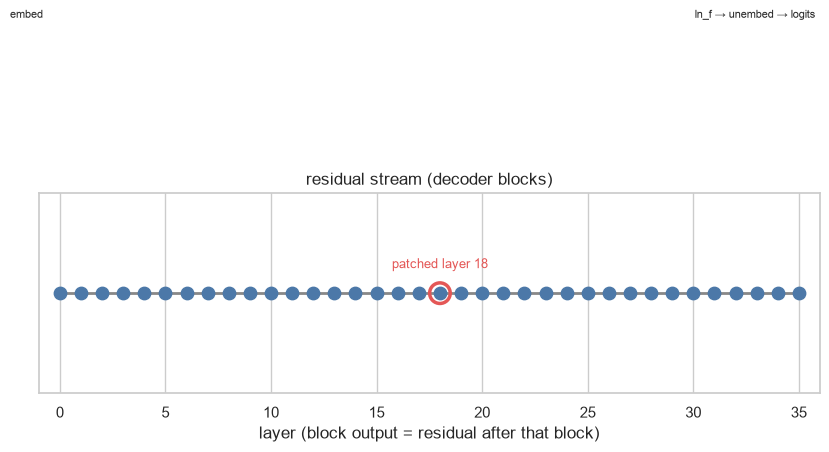

In [32]:
# viz — patch: token streams (lengths must match) + three logits. Orange ring = patched layer.
show_token_stream(tok, enc_c, title="CLEAN")
show_token_stream(tok, enc_x, title="CORRUPT")
show_tensor(clean_h, "clean residual at last token [1, hidden]")

def _logit(t):
    return float(to_cpu_f32(t)[answer_id])

plot_patch_logits(ANSWER, _logit(clean_logits), _logit(corrupt_logits), _logit(patched_logits)).show()
draw_residual_stack(n_layers, highlight=PATCH_LAYER, highlight_label=f"patched layer {PATCH_LAYER}")
plt.show()

## 5. Patch every (layer, position)

Section 4 patched one layer at one position and found nothing (`patch ≈ corrupt`). That is not evidence of absence — it is one cell of a grid, chosen blind. Sweeping the grid turns "this layer matters" into a picture of *where and when* the answer is actually carried.

Read a bright cell as: **the residual at this (layer, position), copied from the clean run, is enough on its own to make the corrupt run answer correctly.** Sufficiency, on this one pair. Not necessity, and not a circuit.

Two choices make the sweep affordable and honest:

- **Cost.** One clean forward caches all 36 layers, and each corrupt forward patches a *different* position in each batch row — so this is ~72 forwards, not 36 × 13 = 468.
- **Metric.** The score is a **logit difference** (`Paris` minus `Rome`), normalised so 0 = the corrupt run and 1 = the clean run. A bare logit would move just because overwriting a slab of residual stream changes how peaked the softmax is, and you would read that as signal.

In [34]:
import numpy as np
from IPython.display import display

import importlib
import src.viz as _viz
importlib.reload(_viz)
from src.patching import component_attribution, patch_residual_sweep, token_labels, top_components
from src.viz import plot_head_attribution, plot_layer_attribution, plot_patch_heatmap

# A wrong answer turns the metric into a difference. "The model prefers Paris to
# Rome" is a claim; "the Paris logit went up" is not, because everything moves
# together when you overwrite a residual.
WRONG = "Rome"
wrong_id = tok.encode(WRONG, add_special_tokens=False)[0]

sweep = patch_residual_sweep(model, enc_c, enc_x, answer_id, wrong_id, batch_positions=8)
rec = sweep["recovered"]
print(f"clean {sweep['clean']:+.2f}   corrupt {sweep['corrupt']:+.2f}   "
      f"(logit {ANSWER!r} − {WRONG!r})")

# Two invariants. If either fails the sweep is lying and nothing below is real.
# 1. The last block's output at the readout position *is* what the unembed sees,
#    so patching it must reproduce the clean run exactly.
assert abs(rec[n_layers - 1, -1] - 1.0) < 0.02, rec[n_layers - 1, -1]
# 2. At layer 0, a position holding the same token in both prompts is a no-op.
shared = [i for i, (a, b) in enumerate(zip(enc_c["input_ids"][0].tolist(),
                                           enc_x["input_ids"][0].tolist())) if a == b]
assert abs(rec[0, shared[0]]) < 0.02, rec[0, shared[0]]
print(f"invariants ok (last-layer readout = {rec[n_layers - 1, -1]:.3f}, "
      f"layer-0 shared token = {rec[0, shared[0]]:.3f})")

labels = token_labels(tok, enc_c)
best_layer, best_pos = np.unravel_index(int(rec.argmax()), rec.shape)
print(f"best single patch: layer {best_layer}, position {best_pos} ({labels[best_pos]!r}) "
      f"recovers {rec[best_layer, best_pos]:.2f}")

fig = plot_patch_heatmap(sweep, labels)
fig.write_html(FIGURES / "patch_sweep.html")
fig.show()

# Write one sentence: which token holds the answer, and at which layer does it
# stop mattering there and start mattering at the readout position?

patching:   0%|          | 0/72 [00:00<?, ?fwd/s]

clean +18.50   corrupt -5.88   (logit 'Paris' − 'Rome')
invariants ok (last-layer readout = 1.000, layer-0 shared token = -0.005)
best single patch: layer 19, position 6 ('6: France') recovers 1.04


## 6. Which components write the answer

Patching says *where* the information is. It cannot say *which component put it there*, because the residual at layer 19 is the sum of everything every earlier layer wrote.

That sum is the whole trick. The model is pre-norm, so the final residual is a plain addition,

\[ x_{\text{final}} = \text{embed} + \sum_{\ell} \left( \text{attn}_\ell + \text{mlp}_\ell \right) \]

and `o_proj` has no bias, so \(\text{attn}_\ell\) splits further into one term per head: head \(h\) contributes \(W_O^{(h)} z_h\). The unembed is linear, and RMSNorm only rescales by a scalar, so the logit difference decomposes exactly:

\[ \text{logit}(\texttt{Paris}) - \text{logit}(\texttt{Rome}) = \frac{1}{\text{rms}} \sum_{c} c \cdot \left( w_{\text{lnf}} \odot (W_U[\texttt{Paris}] - W_U[\texttt{Rome}]) \right) \]

One signed number per component, ~1200 of them. That is **direct logit attribution**, and because it is exact arithmetic, the parts summing back to the model's real logit difference is a genuine test of the hooks — printed below.

Two honest limits. DLA only sees the **last hop**: a head that matters enormously by moving `France` into position for a later head writes nothing to the answer direction itself and shows up as zero. And holding `rms` fixed is fine for describing the run you did, but it means a large attribution is not a promise about what ablating that head would do.

In [ ]:
attr = component_attribution(model, enc_c, answer_id, wrong_id)

# Exact arithmetic, so this is a real check on the hooks: every head, every MLP
# and the embedding must add back up to the model's own logit difference. The
# residual gap is bf16 rounding accumulated over ~1200 components.
gap = abs(attr["total"] - attr["actual"])
print(f"sum of parts {attr['total']:+.3f}   model {attr['actual']:+.3f}   gap {gap:.3f}")
assert gap < 0.5, "decomposition does not reconstruct the logit difference — hooks are wrong"
print(f"embed {attr['embed']:+.2f}   attention {attr['heads'].sum():+.2f}   "
      f"MLP {attr['mlps'].sum():+.2f}")

# Read the table, not the heatmap. A single strongly negative head is invisible
# to the eye in a 36x32 grid and is usually the interesting one.
display(top_components(attr, 10))

fig = plot_head_attribution(attr)
fig.write_html(FIGURES / "head_attribution.html")
fig.show()
plot_layer_attribution(attr).show()

# Checkpoint: is the answer written by a few heads or smeared over many? Does the
# top head sit at the layer the patch sweep pointed at, or later? Later means the
# sweep found where the fact is *stored* and DLA found where it is *read out*.

## Checkpoint

- [ ] Top-5 / greedy decode matched a chat UI for the same user string.
- [ ] `figures/logit_lens.png` exists; you can say in one sentence when the target becomes readable.
- [ ] You read every steered completion, including **random**. Random ≉ steer, or you learned that too.
- [ ] The patch sweep passed both invariants, and you can name the token and layer where the answer becomes recoverable.
- [ ] The attribution summed back to the model's own logit difference, and you looked at the table as well as the heatmap.
- [ ] No SAE, no finetune.

Keep this kernel up (`model` is already loaded).

Next, and one at a time: run the sweep on a **second** clean/corrupt pair before believing the first one; or check whether the top head from section 6 is actually *necessary* by ablating it, since DLA only shows sufficiency of what it writes; or tighten the steering dataset. The composition question — which heads feed the top head — is what ARENA 1.2's induction-head material teaches, and this notebook does not answer it.